In [1]:
import os, sys
PROJECT_ROOT = os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

import pickle
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from cmcrameri import cm

import utils_inverse

%load_ext autoreload
%autoreload 2

# Seed uncertainty sweep (Reviewer Point 1) - CO2-only results

Companion notebook for `scripts/6a_seed_uncertainty_sweep.py`. Reproduces the CO2-only quantitative results behind Figures 3 and 4, across 5 independent MLP-init seeds (0-4), reporting mean +/- spread instead of a single-seed point estimate.

**Scope so far**: CO2-only, expensive axis (independent full outer-loop re-optimizations) only. Other agent groups (CH4/N2O/Sulfur/BC/multi-agent) and the cheap axis (emulator-only retrain seeds) are tracked separately in `REVISIONS.md` and not yet included here.

All 30 expensive-axis runs (5 seeds x 6 groups: H-ext, tier1, tier2, DECK, CS3, all) completed with zero NaN/Inf instabilities. The main finding: for every group except `H-ext`, seed-to-seed standard deviation in final loss is comparable to or larger than the mean itself - see the per-panel spread below.

## Figure 3 (CO2 panel): NRMSE vs. optimization step, with seed spread

Recreates the manuscript's `tier1` CO2 panel (loglog training-objective NRMSE vs. outer-loop update step), plus the other 5 experiment groups for additional diagnostic coverage. Each panel shows the mean curve across 5 seeds with a shaded min-max envelope, against the single fixed baseline-emulator reference line used in the original figure.

In [2]:
import importlib.util as _ilu

def _load_experiments_module(path):
    spec = _ilu.spec_from_file_location("_exp_mod", path)
    mod = _ilu.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

exp_mod = _load_experiments_module(os.path.join(PROJECT_ROOT, "scripts", "3a_inverse_CO2_only.py"))
SEEDS = [0, 1, 2, 3, 4]
GROUPS = list(exp_mod.EXPERIMENTS)  # H-ext, tier1, tier2, DECK, CS3, all

fig3_errors = {}  # group -> (n_seeds, n_steps) array of training-objective NRMSE
for group in GROUPS:
    cfg = exp_mod.EXPERIMENTS[group]
    curves = []
    for seed in SEEDS:
        path = f"checkpoints/co2/seed_sweep/inverse_{cfg['init_cond']}_{cfg['group']}_{cfg['tag']}_seed{seed}.pkl"
        ck = utils_inverse.load_inverse_ckpt(path)
        curves.append(np.asarray(ck["errors"]))
    fig3_errors[group] = np.stack(curves, axis=0)

with open("data/plotting/baseline_co2_only.pkl", "rb") as f:
    baseline_co2 = pickle.load(f)
baseline_ref = baseline_co2["Tier 1"]["mean"]

{g: fig3_errors[g].shape for g in GROUPS}

{'H-ext': (5, 1001),
 'tier1': (5, 1001),
 'tier2': (5, 1001),
 'DECK': (5, 1001),
 'CS3': (5, 1001),
 'all': (5, 1001)}

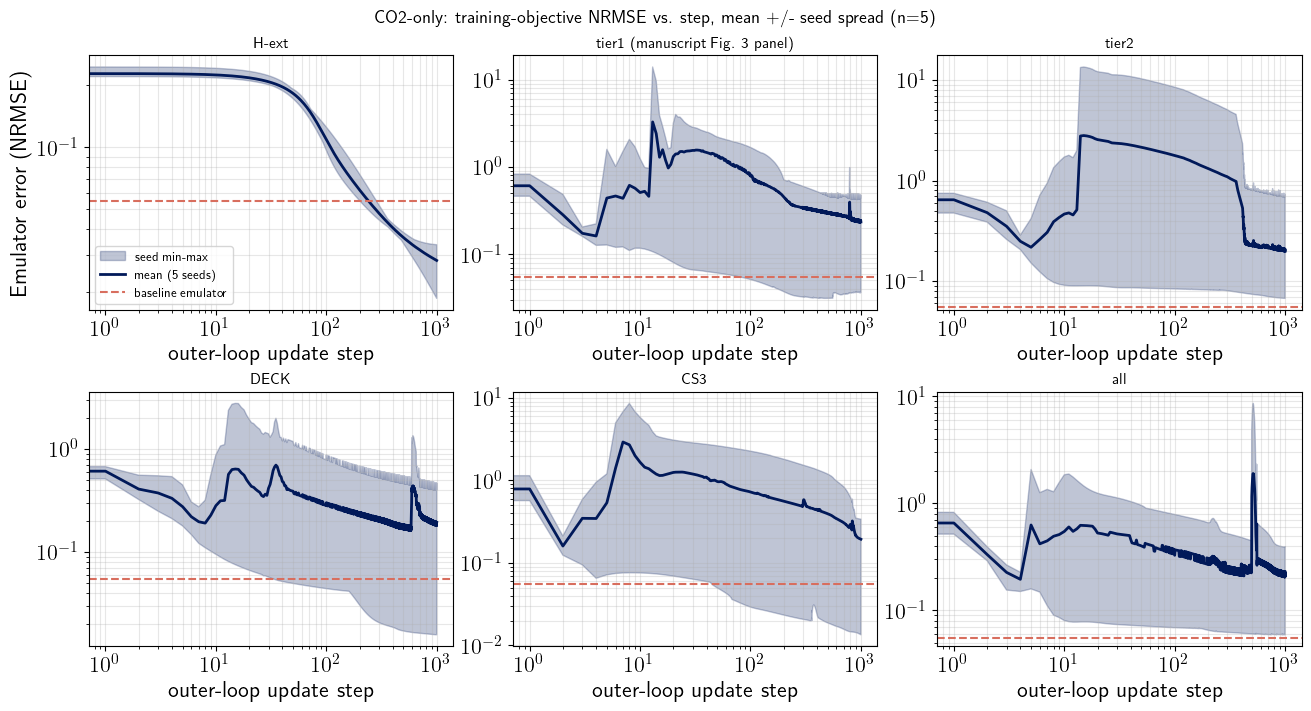

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
axes = axes.flatten()
manuscript_group = "tier1"

for ax, group in zip(axes, GROUPS):
    curves = fig3_errors[group]  # (5, n_steps)
    steps = np.arange(curves.shape[1])
    mean_curve = curves.mean(axis=0)
    lo, hi = curves.min(axis=0), curves.max(axis=0)

    ax.fill_between(steps, lo, hi, color=cm.batlowS(0), alpha=0.25, label="seed min-max")
    ax.loglog(steps, mean_curve, color=cm.batlowS(0), lw=2, label="mean (5 seeds)")
    ax.axhline(baseline_ref, ls="--", color=cm.lipariS(5), lw=1.5, label="baseline emulator")

    title = group + ("  (manuscript Fig. 3 panel)" if group == manuscript_group else "")
    ax.set_title(title, fontsize=11, fontweight="bold" if group == manuscript_group else "normal")
    ax.grid(True, alpha=0.3, which="both")
    ax.set_xlabel("outer-loop update step")
    if ax is axes[0]:
        ax.set_ylabel("Emulator error (NRMSE)")
        ax.legend(fontsize=9, loc="best")

plt.suptitle("CO2-only: training-objective NRMSE vs. step, mean +/- seed spread (n=5)", fontsize=13)
plt.show()

## Figure 4, panel (a) CO2-only: performance summary, with seed spread

Recreates the CO2-only panel of the performance-summary bar chart (% NRMSE improvement of the optimized emulator over the fixed baseline emulator, per cross-eval scenario set). Each of the 5 seeds' checkpoints is re-evaluated with `evaluate_optimal_emulator` using that seed's own `params0` (the same init its outer-loop optimization actually used); the baseline denominator is the single original (seed-independent) baseline emulator, so the spread shown here isolates variance from the optimization seed alone.

In [4]:
TRAIN_SCENARIOS = ["Opt. Tier 1", "Opt. Tier 2", "Opt. DECK", "Opt. CS3", "Opt. All"]
TEST_SCENARIOS = ["Tier 1", "Tier 2", "DECK", "CS3"]
WEIGHTS = np.array([7, 5, 2, 2])  # matches Fig 4's original scenario-count weights

with open("data/SI_results/seed_uncertainty/fig4_eval_spread_3a_inverse_CO2_only.pkl", "rb") as f:
    fig4_by_seed = pickle.load(f)

base_errors = np.array([baseline_co2[t]["mean"] for t in TEST_SCENARIOS])
avg_base_error = np.average(base_errors, weights=WEIGHTS)

n_seeds = len(fig4_by_seed)
# rows: one per test scenario, plus a weighted "Avg." row (matches plot_grouped_improvement_bars)
pct_improvement = np.zeros((n_seeds, len(TEST_SCENARIOS) + 1, len(TRAIN_SCENARIOS)))
for si, seed in enumerate(sorted(fig4_by_seed)):
    results = fig4_by_seed[seed]
    opt_errors = np.array([[results[tr][te]["mean"] for tr in TRAIN_SCENARIOS] for te in TEST_SCENARIOS])
    pct = (base_errors[:, None] - opt_errors) / base_errors[:, None] * 100
    avg_opt = np.average(opt_errors, axis=0, weights=WEIGHTS)
    avg_pct = (avg_base_error - avg_opt) / avg_base_error * 100
    pct_improvement[si, : len(TEST_SCENARIOS), :] = pct
    pct_improvement[si, -1, :] = avg_pct

pct_mean = pct_improvement.mean(axis=0)  # (rows, train_scenarios)
pct_std = pct_improvement.std(axis=0)
row_labels = TEST_SCENARIOS + ["Avg."]

pct_mean.shape, pct_std.shape

((5, 5), (5, 5))

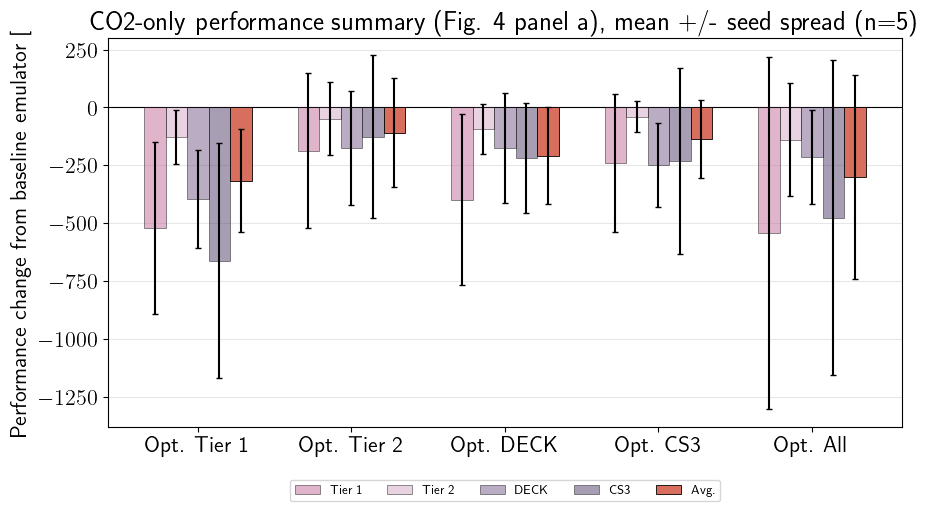

Note: unlike the manuscript figure, this does not clip/hatch extreme values at
+/-60% - Stage 6f (Point 6) builds the dedicated exact-value transparency table.


In [5]:
fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
n_rows = len(row_labels)
n_cols = len(TRAIN_SCENARIOS)
x = np.arange(n_cols)
total_width = 0.7
bar_w = total_width / n_rows

for i, label in enumerate(row_labels):
    offset = (i - n_rows / 2) * bar_w + (bar_w / 2)
    color = cm.actonS(i + 2) if i < 4 else cm.lipariS(5)
    alpha = 0.5 if i < 4 else 1.0
    ax.bar(
        x + offset, pct_mean[i], width=bar_w, yerr=pct_std[i], capsize=2,
        label=label, color=color, alpha=alpha, edgecolor="black", linewidth=0.6, zorder=3,
    )

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(TRAIN_SCENARIOS)
ax.set_ylabel("Performance change from baseline emulator [%]")
ax.set_title("CO2-only performance summary (Fig. 4 panel a), mean +/- seed spread (n=5)")
ax.legend(fontsize=9, ncols=5, loc="upper center", bbox_to_anchor=(0.5, -0.12))
ax.grid(True, alpha=0.3, axis="y")
plt.show()

print("Note: unlike the manuscript figure, this does not clip/hatch extreme values at")
print("+/-60% - Stage 6f (Point 6) builds the dedicated exact-value transparency table.")

## Notes

- Full per-run data: `data/SI_results/seed_uncertainty/expensive_sweep_3a_inverse_CO2_only.csv` (Fig 3 axis) and `fig4_eval_spread_3a_inverse_CO2_only.pkl` (Fig 4 axis).
- Not yet covered here: CH4/N2O/Sulfur/BC/multi-agent groups (Figs 3/4/6), the cheap axis (emulator-only retrain seeds, per the reviewer's "at least emulator-training seeds" ask), and Fig 6/7. Tracked in `REVISIONS.md` Stage 6a.
- See `REVISIONS.md`'s session log for the full CO2-only expensive-axis spread numbers and the `tier2` seed-1 bad-optimum finding.